<a href="https://colab.research.google.com/github/MohHaroon/XAI-based-ZSL-for-IIDS/blob/master/Benchmark_ZSAL_and_SOAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Implementation of the Zero-Shot Attribution Layer and SHAP Overlap Automation Model (SOAM)

## Load CatBoost model and data splits -
### SDN Dataset

In [1]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.8 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [75]:
# Reloading CatBoost
from catboost import CatBoostClassifier
loaded_cat = CatBoostClassifier()
loaded_cat.load_model('/content/drive/MyDrive/IRP_Models/catboost_3UNRIDD_20260225_205205.cbm')

CatBoostClassifier(depth=1, iterations=1, learning_rate=0.1, loss_function='Logloss', verbose=0)

In [66]:
import os
import joblib
import pandas as pd

base_path = '/content/drive/MyDrive/IRP_Models/Data_Splits/'
split_path = os.path.join(base_path, 'UNR-IDD/')

X_train = joblib.load(os.path.join(split_path, f'X_train.pkl'))
X_test = joblib.load(os.path.join(split_path, f'X_test.pkl'))
y_train = joblib.load(os.path.join(split_path, f'y_train.pkl'))
y_test = joblib.load(os.path.join(split_path, f'y_test.pkl'))

#### Edge-IIoTset
# feature_names = ['arp.opcode', 'arp.hw.size', 'icmp.checksum', 'icmp.seq_le',
#        'icmp.unused', 'http.content_length', 'http.request.method',
#        'http.referer', 'http.request.version', 'http.response',
#        'http.tls_port', 'tcp.ack', 'tcp.ack_raw', 'tcp.checksum',
#        'tcp.connection.fin', 'tcp.connection.rst', 'tcp.connection.syn',
#        'tcp.connection.synack', 'tcp.flags', 'tcp.flags.ack', 'tcp.len',
#        'tcp.seq', 'udp.stream', 'udp.time_delta', 'dns.qry.name',
#        'dns.qry.name.len', 'dns.qry.qu', 'dns.qry.type', 'dns.retransmission',
#        'dns.retransmit_request', 'dns.retransmit_request_in',
#        'mqtt.conack.flags', 'mqtt.conflag.cleansess', 'mqtt.conflags',
#        'mqtt.hdrflags', 'mqtt.len', 'mqtt.msg_decoded_as', 'mqtt.msgtype',
#        'mqtt.proto_len', 'mqtt.protoname', 'mqtt.topic', 'mqtt.topic_len',
#        'mqtt.ver', 'mbtcp.len', 'mbtcp.trans_id', 'mbtcp.unit_id']

# #### UNR-IDD
feature_names = ['Received Packets', 'Received Bytes', 'Sent Bytes', 'Sent Packets',
       'Port alive Duration (S)', 'Delta Received Packets',
       'Delta Received Bytes', 'Delta Sent Bytes', 'Delta Sent Packets',
       'Delta Port alive Duration (S)', 'Connection Point', 'Total Load/Rate',
       'Total Load/Latest', 'Unknown Load/Rate', 'Unknown Load/Latest',
       'Latest bytes counter', 'Active Flow Entries', 'Packets Looked Up',
       'Packets Matched']

X_test = pd.DataFrame(X_test, columns=feature_names)
X_train = pd.DataFrame(X_train, columns=feature_names)

# Align indices of y_train and y_test with the newly created DataFrames
# X_train and X_test received a new RangeIndex when converted to DataFrame.
# y_train and y_test need their indices reset to match for consistent indexing.
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print(f"\nSuccessfully loaded Data Splits for {len(X_test)} test packets.")


Successfully loaded Data Splits for 749 test packets.


In [54]:
print(len(X_train))

2992


In [55]:
print(len(X_test))

749


## Zero-Shot Attribution Layer (ZSAL)

### Generating SHAP values and plot

In [76]:
import shap

# Initialize Explainer
explainer = shap.TreeExplainer(loaded_cat)

# Simulating SDIN Monitoring
print("Monitoring SDN Traffic...")
found_anomaly = False

for i in range(len(X_test)):
    # Get a single packet instance
    instance = X_test.iloc[i:i+1]

    # Inference
    prediction = loaded_cat.predict(instance)[0]

    if prediction == 1:  # Anomaly
        print(f"ALARM: Anomaly detected at packet index {i}")

        # Generate SHAP values
        instance_shap = explainer.shap_values(instance)

        shap.force_plot(explainer.expected_value, instance_shap[0], instance, matplotlib=True)

        # for ZSAL Labeling
        target_instance = instance
        target_shap = instance_shap[0]
        found_anomaly = True
        break

if not found_anomaly:
    print("No anomalies detected in the current traffic batch.")

Monitoring SDN Traffic...


CatBoostError: catboost/libs/data/model_dataset_compatibility.cpp:72: Feature 25 is present in model but not in pool.

In [ ]:
print(instance)

   proto_number       Dur      Mean    Stddev       Min       Max      Pkts  \
0        0.3125  0.001966  0.029177  0.121601  0.000411  0.192954  0.055428   

      Bytes     Spkts     Dpkts  ...     Drate       Sum  TnBPSrcIP  \
0  0.052419  0.000008  0.000005  ...  0.000012  0.027426   0.058714   

   TnBPDstIP  TnP_PSrcIP  TnP_PDstIP  TnP_PerProto  TnP_Per_Dport  \
0   0.041362    0.056576    0.056573      0.055426       0.016501   

   N_IN_Conn_P_DstIP  N_IN_Conn_P_SrcIP  
0           0.000043           0.000102  

[1 rows x 23 columns]


In [ ]:
print(target_shap)

[-1.51216400e+00  1.13995426e+00 -1.38686255e-01 -2.22529640e-01
 -8.70683341e-04 -9.08581498e-01  9.87232053e-01 -3.37505351e-01
  2.06964538e-01  2.43054045e+00  2.81709370e+00  7.57021343e+00
  9.14810218e-02 -4.95600218e-01  1.04016687e+00  1.65754870e-01
  7.82980058e-02  5.00120688e-01 -1.58382783e-01  1.22069291e-01
  3.08664532e-01 -7.86516621e-02 -5.59460870e-01]


In [ ]:
print(instance_shap)

[[-1.51216400e+00  1.13995426e+00 -1.38686255e-01 -2.22529640e-01
  -8.70683341e-04 -9.08581498e-01  9.87232053e-01 -3.37505351e-01
   2.06964538e-01  2.43054045e+00  2.81709370e+00  7.57021343e+00
   9.14810218e-02 -4.95600218e-01  1.04016687e+00  1.65754870e-01
   7.82980058e-02  5.00120688e-01 -1.58382783e-01  1.22069291e-01
   3.08664532e-01 -7.86516621e-02 -5.59460870e-01]]


In [ ]:
print(explainer.expected_value)

5.984509674509375


In [57]:
import shap
import matplotlib.pyplot as plt
import pandas as pd

shap_explanation = shap.Explanation(
    values=target_shap,               # The SHAP values for this instance
    base_values=explainer.expected_value, # The average model output
    data=instance.iloc[0],         # The actual feature values for this row
    feature_names=instance.columns
)

plt.figure(figsize=(12, 8))
shap.plots.bar(shap_explanation, max_display=24, show=False)

plt.title(f"Feature Contributors for Anomaly (Packet Index {i})", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

NameError: name 'target_shap' is not defined

### Attribute the Anomaly with a label

In [68]:
import shap
explainer = shap.TreeExplainer(loaded_cat)
def generate_zasl_label(shap_values, feature_names):

    positive_contributions = [(val, name) for val, name in zip(shap_values, feature_names) if val > 0]
    # Sort by impact (highest value first)
    sorted_contributions = sorted(positive_contributions, key=lambda x: x[0], reverse=True)

    # Extract top features
    top_features = [item[1] for item in sorted_contributions[:3]]
    high_impact_extra = [item[1] for item in sorted_contributions[3:] if item[0] > 2]

    final_feature_list = top_features + high_impact_extra

    if not top_features:
        return "Generic Anomaly"

    return f"{'-'.join(final_feature_list)}-based-Attribution"



In [ ]:
zasl_name = generate_zasl_label(target_shap, feature_names)
print(f"ZASL Final Label: {zasl_name}")

## SHAP Overlap Automation Model (SOAM)

### Generate mean SHAP values for TP and FP

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

train_subset = X_train.sample(1000, random_state=42)
train_subset_labels = y_train.loc[train_subset.index]
shap_values_train = explainer.shap_values(train_subset)

# 2. Segment indices based on model performance on the training data
# Use the correct model object: `loaded_cat` instead of `cat_model`
train_preds = loaded_cat.predict(train_subset)
tp_indices = np.where((train_preds == 1) & (train_subset_labels == 1))[0]
fp_indices = np.where((train_preds == 1) & (train_subset_labels == 0))[0]

# 3. Calculate the Mean SHAP Profiles (The "Reference Knowledge")
tp_mean_profile = shap_values_train[tp_indices].mean(axis=0)
fp_mean_profile = shap_values_train[fp_indices].mean(axis=0)

print(f"SOAM Baselines Created: {len(tp_indices)} TPs and {len(fp_indices)} FPs utilized.")

CatBoostError: catboost/libs/data/model_dataset_compatibility.cpp:72: Feature 25 is present in model but not in pool.

In [30]:
# 1. Identify indices for correctly classified Normal traffic in the training subset
# Assumes you have train_preds and train_subset_labels from our previous step
tn_indices = np.where((train_preds == 0) & (train_subset_labels == 0))[0]

# 2. Calculate the Mean Normal SHAP Profile
normal_mean_profile = shap_values_train[tn_indices].mean(axis=0)

print(f"Final SOAM Baseline Created: {len(tn_indices)} True Negatives utilized.")

Final SOAM Baseline Created: 4140 True Negatives utilized.


In [31]:
fn_indices = np.where((train_preds == 0) & (train_subset_labels == 1))[0]

# 2. Calculate the Mean Normal SHAP Profile
fn_mean_profile = shap_values_train[fn_indices].mean(axis=0)
print(f"Final SOAM Baseline Created: {len(fn_indices)} False Negatives utilized.")

Final SOAM Baseline Created: 15673 False Negatives utilized.


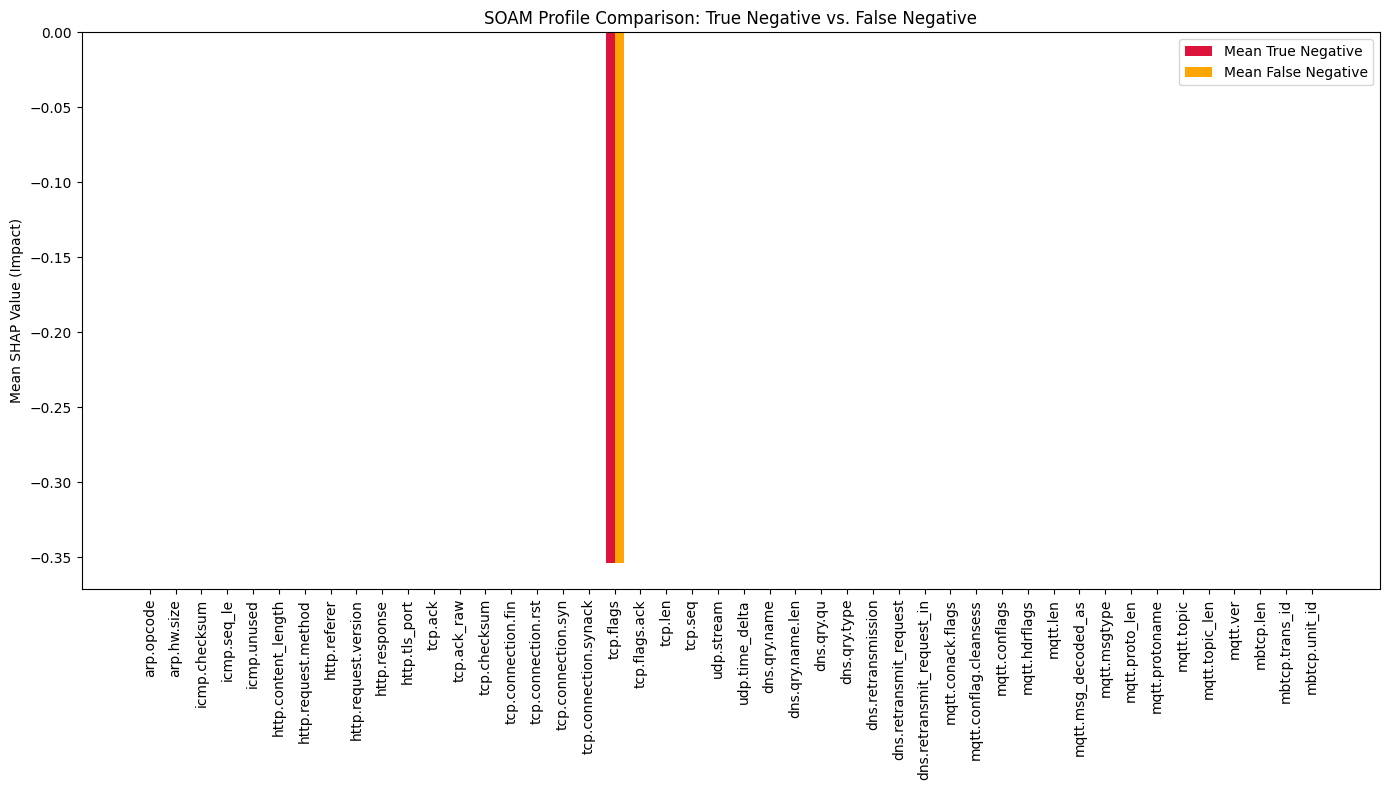

In [32]:
# 4. Comparative Bar Plot for SOAM Diagnosis
feature_names = X_train.columns
x = np.arange(len(feature_names))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 8))
rects1 = ax.bar(x - width/2, normal_mean_profile, width, label='Mean True Negative', color='crimson')
rects4 = ax.bar(x + width/2, fn_mean_profile, width, label='Mean False Negative', color='orange')

ax.set_ylabel('Mean SHAP Value (Impact)')
ax.set_title('SOAM Profile Comparison: True Negative vs. False Negative')
ax.set_xticks(x)
ax.set_xticklabels(feature_names, rotation=90)
ax.legend()

plt.tight_layout()
plt.show()

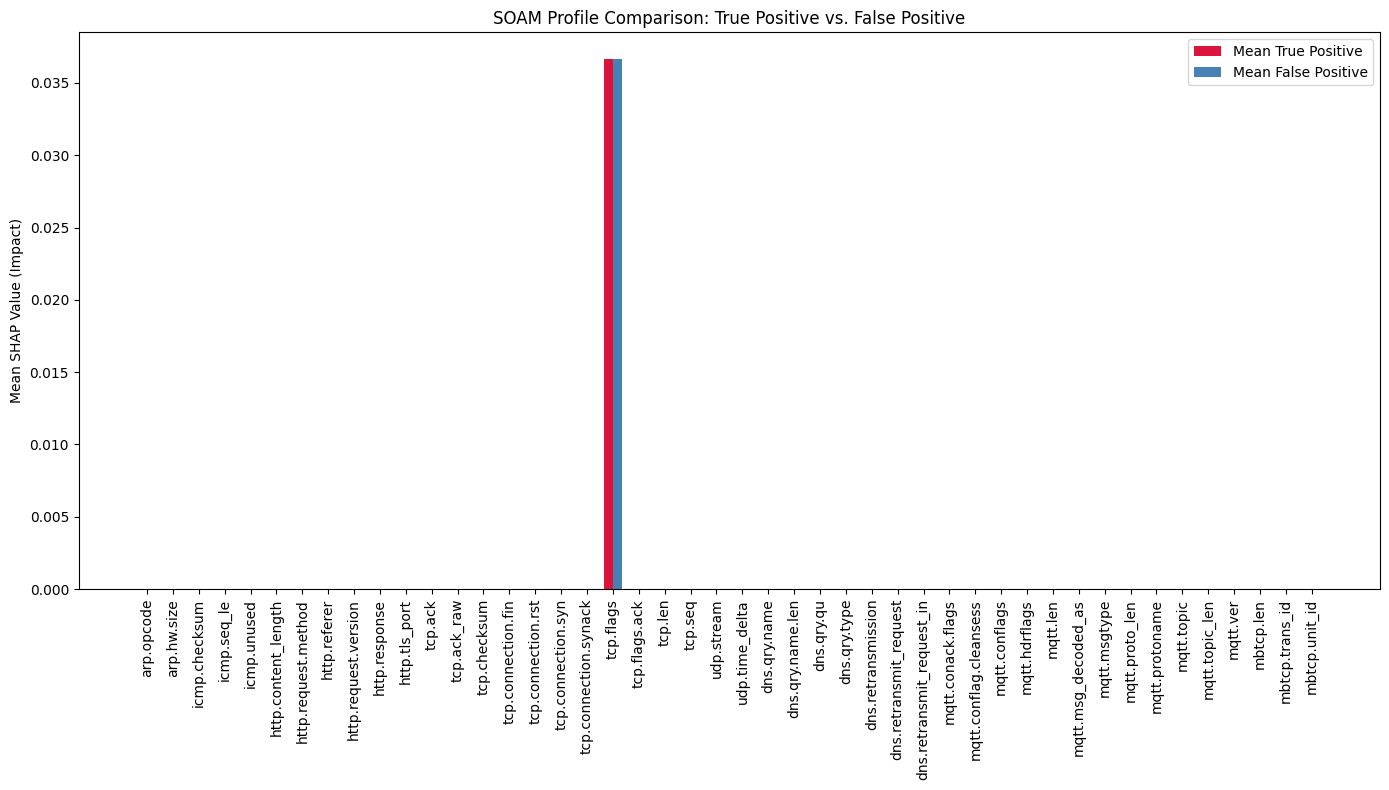

In [33]:
# 4. Comparative Bar Plot for SOAM Diagnosis
feature_names = X_train.columns
x = np.arange(len(feature_names))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 8))
rects1 = ax.bar(x - width/2, tp_mean_profile, width, label='Mean True Positive', color='crimson')
rects2 = ax.bar(x + width/2, fp_mean_profile, width, label='Mean False Positive', color='steelblue')

ax.set_ylabel('Mean SHAP Value (Impact)')
ax.set_title('SOAM Profile Comparison: True Positive vs. False Positive')
ax.set_xticks(x)
ax.set_xticklabels(feature_names, rotation=90)
ax.legend()

plt.tight_layout()
plt.show()

### Save Mean SHAP values

In [34]:
import joblib
import os
from datetime import datetime

# 1. Setup the save path specifically for SOAM Baselines
soam_path = '/content/drive/MyDrive/IRP_Models/SOAM_Baselines/IIoTset/3run/'
if not os.path.exists(soam_path):
    os.makedirs(soam_path)

# 2. Use the same timestamp logic for consistency
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# 3. Save the Mean Profiles (The "Gold Standard")
joblib.dump(tp_mean_profile, f'{soam_path}tp_mean_profile_{timestamp}.pkl')
joblib.dump(fp_mean_profile, f'{soam_path}fp_mean_profile_{timestamp}.pkl')

print(f"SOAM Baseline Profiles saved successfully at: {soam_path}")
print(f"Timestamp: {timestamp}")

SOAM Baseline Profiles saved successfully at: /content/drive/MyDrive/IRP_Models/SOAM_Baselines/IIoTset/3run/
Timestamp: 20260225_203009


In [35]:
soam_path = '/content/drive/MyDrive/IRP_Models/SOAM_Baselines/IIoTset/3run/'
# 3. Save it to your SOAM Baselines folder
joblib.dump(normal_mean_profile, f'{soam_path}normal_mean_profile_{timestamp}.pkl')

joblib.dump(fn_mean_profile, f'{soam_path}fn_mean_profile_{timestamp}.pkl')

['/content/drive/MyDrive/IRP_Models/SOAM_Baselines/IIoTset/3run/fn_mean_profile_20260225_203009.pkl']

## Load SHAP profiles

In [37]:
soam_path = '/content/drive/MyDrive/IRP_Models/SOAM_Baselines/IIoTset/3run/'

# Loading back for the final similarity check
tp_mean = joblib.load(f'{soam_path}tp_mean_profile_20260225_203009.pkl')
fp_mean = joblib.load(f'{soam_path}fp_mean_profile_20260225_203009.pkl')
normal_mean = joblib.load(f'{soam_path}normal_mean_profile_20260225_203009.pkl')
fn_mean = joblib.load(f'{soam_path}fn_mean_profile_20260225_203009.pkl')

### Calculate Confidence

In [38]:
def calculate_weighted_soam(instance_shap, mean_profile):
    from scipy.spatial.distance import cosine
    from scipy.stats import spearmanr
    import numpy as np

    # 1. Cosine Similarity (Weight: 50%)
    cos_sim = 1 - cosine(instance_shap, mean_profile)

    # 2. Spearman Rank Correlation (Weight: 25%)
    spearman_corr, _ = spearmanr(instance_shap, mean_profile)

    # Calculate absolute differences for each feature
    absolute_diffs = np.abs(instance_shap - mean_profile)
    # Calculate the mean of these differences
    mad_score = np.mean(absolute_diffs)

    # 3. Jaccard-style Sign Overlap (Weight: 25%)
    instance_signs = np.sign(instance_shap)
    mean_signs = np.sign(mean_profile)
    sign_overlap = (instance_signs == mean_signs).mean()

    # 4. Final Weighted Aggregation
    weighted_score = (0.70 * cos_sim) + (0.1 * spearman_corr) + (0.1 * sign_overlap) + (0.1 * mad_score)


    return {
        "Cosine": cos_sim,
        "Spearman": spearman_corr,
        "Sign_Overlap": sign_overlap,
        "MAD": mad_score,
        "Weighted_Reliability": weighted_score
    }

In [39]:
def get_soam_verdict(instance_shap, tp_mean, fp_mean):


    # Calculate scores for both reference groups
    tp_scores = calculate_weighted_soam(instance_shap, tp_mean)
    #print("Cosine, SPearman, Sign_Overlap, MAD for tp", tp_scores['Cosine'], tp_scores['Spearman'], tp_scores['Sign_Overlap'],tp_scores['MAD'])

    fp_scores = calculate_weighted_soam(instance_shap, fp_mean)
    #print("Cosine, SPearman, Sign_Overlap, MAD for fp", fp_scores['Cosine'], fp_scores['Spearman'], fp_scores['Sign_Overlap'], fp_scores['MAD'])

    tp_rel = tp_scores['Weighted_Reliability']
    fp_rel = fp_scores['Weighted_Reliability']

    # Logic to determine the final system action
    if tp_rel > fp_rel and (tp_rel-fp_rel) > 0.15:
        verdict = f"CONFIRMED ATTACK"
        action = "Display in System"
        "SUSPECT Attack (Potential False Negative)", "MEDIUM - For Analyst Review"
    elif fp_rel > tp_rel:
        verdict = f"SUSPECT Attack (Potential False Positive)"
        action = "LOW - For Analyst Review"
    else:
        verdict = "SUSPECT Attack (Potential True Positive)"
        action = "HIGH - For Analyst Review"

    return {
        "Verdict": verdict,
        "Action": action,
        "TrueProfile_Similarity": tp_rel,
        "FalseProfile_Similarity": fp_rel
    }

In [40]:
def get_soam_verdict_NormalValidation(instance_shap, normal_mean, fp_mean):
    # Calculate similarity to Normal baseline
    normal_sim = calculate_weighted_soam(instance_shap, normal_mean)['Weighted_Reliability']
    # Calculate similarity to False Positive (Missed Attack) baseline
    fn_sim = calculate_weighted_soam(instance_shap, fn_mean)['Weighted_Reliability']
    #print(f"Similarity to Normal Baseline: {normal_sim:.4f}")
    #print(f"Similarity to False Positive (Missed Attack) Baseline: {fn_sim:.4f}")

    if fn_sim > normal_sim and fn_sim > 0.4:
        #target_shap = instance_shap[0]
        label = generate_zasl_label(instance_shap, X_test.columns.tolist())
        verdict = "SUSPECT Attack (Potential False Negative)"
        action = "MEDIUM - For Analyst Review"
        return {
                "Label": label,
                "Verdict": verdict,
                "Action": action,
                "TrueProfile_Similarity": normal_sim,
                "FalseProfile_Similarity": fn_sim
            }
    label = "Normal Traffic"
    verdict = "NORMAL Traffic"
    action = "No Action Required"
    return {
                "Label": label,
                "Verdict": verdict,
                "Action": action,
                "TrueProfile_Similarity": normal_sim,
                "FalseProfile_Similarity": fn_sim
            }

In [ ]:
# Execute the final component check
verdict_results = get_soam_verdict(target_shap, tp_mean_profile, fp_mean_profile)
print(f"Final System Verdict: {verdict_results['Verdict']}")
print(f"Action: {verdict_results['Action']}")

Cosine, SPearman, Sign_Overlap, MAD for tp -0.36646452919145567 -0.12845849802371542 0.4782608695652174 1.7064859035434197
Cosine, SPearman, Sign_Overlap, MAD for fp 0.38362226310795045 0.2440711462450593 0.6086956521739131 1.4647080108827224
Final System Verdict: SUSPECT Attack (Potential False Positive) = 50.03%
Action: Low - For Analyst Review


# Simulation

Analyzing 100 packets for Reliability Gap...


/tmp/ipython-input-16203319.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Ground Truth', y='TP_Similarity_Score', data=stress_df, palette=palette, width=0.5)


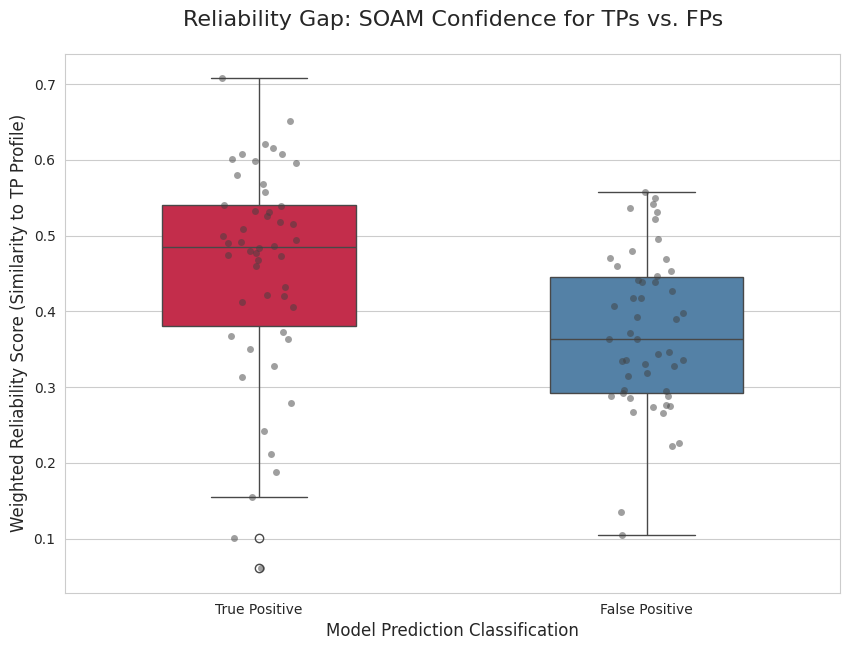

Mean Reliability Gap: 0.0834


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Select 50 TPs and 50 FPs from the Test Set
test_preds = loaded_cat.predict(X_test)
tp_indices = np.where((test_preds == 1) & (y_test == 1))[0][:50]
fp_indices = np.where((test_preds == 1) & (y_test == 0))[0][:50]

all_test_indices = np.concatenate([tp_indices, fp_indices])
stress_results = []

print("Analyzing 100 packets for Reliability Gap...")

# 2. Automated Loop for Metrics
for idx in all_test_indices:
    instance = X_test.iloc[idx:idx+1]
    # Use the existing explainer and profiles
    instance_shap = explainer.shap_values(instance)[0]

    # Calculate Similarity to 'Gold Standard' TP Profile
    tp_metrics = calculate_weighted_soam(instance_shap, tp_mean_profile)

    stress_results.append({
        'Ground Truth': 'True Positive' if idx in tp_indices else 'False Positive',
        'TP_Similarity_Score': tp_metrics['Weighted_Reliability']
    })

stress_df = pd.DataFrame(stress_results)

# 3. Create the Visualization
plt.figure(figsize=(10, 7))
sns.set_style("whitegrid")
palette = {"True Positive": "crimson", "False Positive": "steelblue"}

ax = sns.boxplot(x='Ground Truth', y='TP_Similarity_Score', data=stress_df, palette=palette, width=0.5)
sns.stripplot(x='Ground Truth', y='TP_Similarity_Score', data=stress_df, color=".25", alpha=0.5)

plt.title('Reliability Gap: SOAM Confidence for TPs vs. FPs', fontsize=16, pad=20)
plt.ylabel('Weighted Reliability Score (Similarity to TP Profile)', fontsize=12)
plt.xlabel('Model Prediction Classification', fontsize=12)

# Save for your final report
plt.savefig('SOAM_Reliability_Gap.png', dpi=300)
plt.show()

# Print the Mean Gap for your Results section
mean_tp = stress_df[stress_df['Ground Truth'] == 'True Positive']['TP_Similarity_Score'].mean()
mean_fp = stress_df[stress_df['Ground Truth'] == 'False Positive']['TP_Similarity_Score'].mean()
print(f"Mean Reliability Gap: {mean_tp - mean_fp:.4f}")

# Validate Normal Traffic

Monitoring SDN Traffic...
ALARM: Anomaly detected at packet index 8


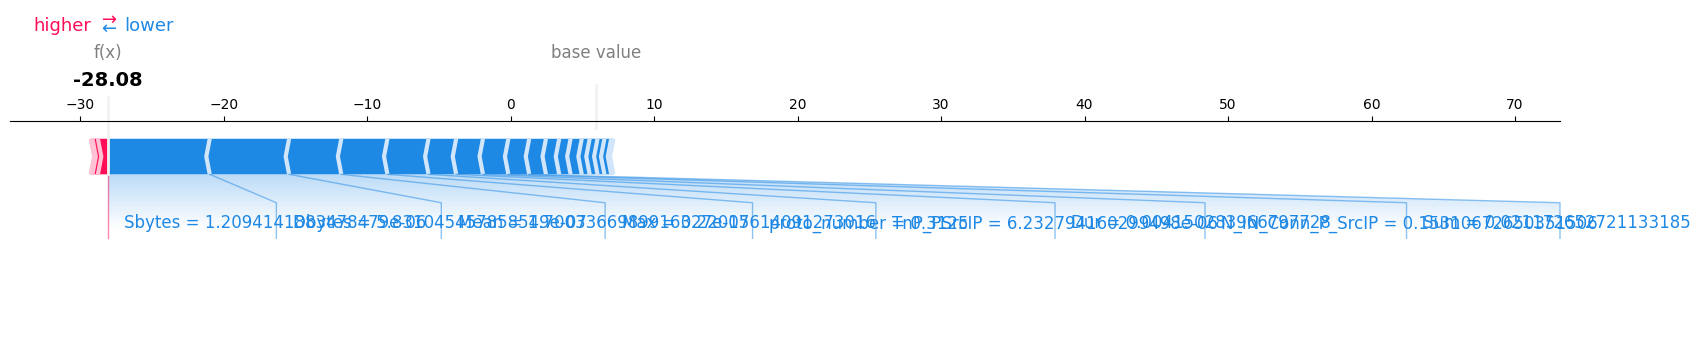

In [ ]:
##Normal Traffic

import shap

# Initialize Explainer
explainer = shap.TreeExplainer(loaded_cat)

# Simulating SDIN Monitoring
print("Monitoring SDN Traffic...")
found_anomaly = False

for i in range(len(X_test)):
    # Get a single packet instance
    instance = X_test.iloc[i:i+1]

    # Inference
    prediction = loaded_cat.predict(instance)[0]

    if prediction == 0:  # Anomaly
        print(f"ALARM: Anomaly detected at packet index {i}")

        # Generate SHAP values
        instance_shap = explainer.shap_values(instance)

        shap.force_plot(explainer.expected_value, instance_shap[0], instance, matplotlib=True)

        # for ZSAL Labeling
        target_instance = instance
        target_shap = instance_shap[0]
        found_anomaly = True
        break

if not found_anomaly:
    print("No anomalies detected in the current traffic batch.")

In [ ]:
print(instance)

   proto_number      Dur      Mean    Stddev  Min       Max     Pkts  \
8        0.3125  0.00415  0.000017  0.002777  0.0  0.220176  0.03668   

      Bytes     Spkts     Dpkts  ...     Drate       Sum  TnBPSrcIP  \
8  0.058352  0.000008  0.000005  ...  0.000012  0.021173   0.000011   

   TnBPDstIP  TnP_PSrcIP  TnP_PDstIP  TnP_PerProto  TnP_Per_Dport  \
8   0.052622    0.000006    0.042786      0.036678       0.011913   

   N_IN_Conn_P_DstIP  N_IN_Conn_P_SrcIP  
8           0.080664           0.153107  

[1 rows x 23 columns]


In [ ]:
print(explainer.expected_value)

5.984509674509375


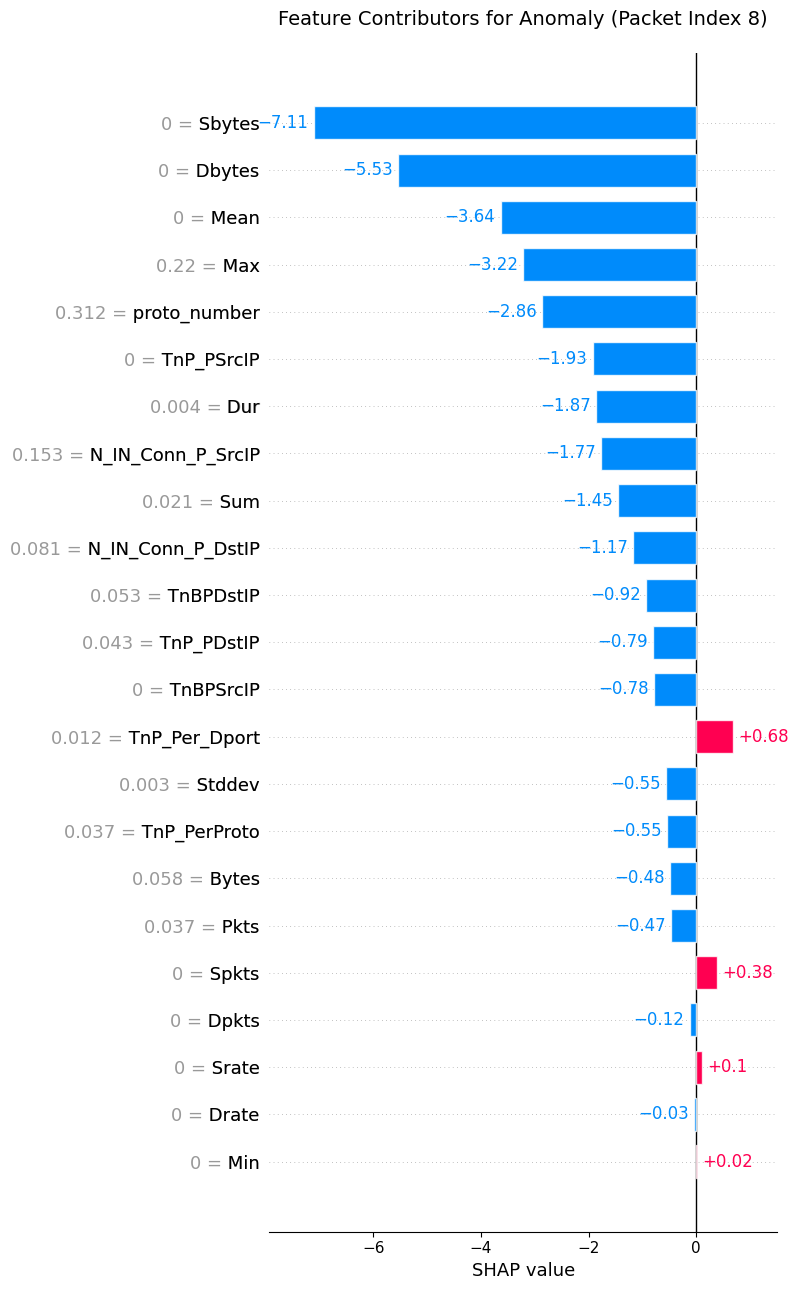

In [ ]:
import shap
import matplotlib.pyplot as plt
import pandas as pd

shap_explanation = shap.Explanation(
    values=target_shap,               # The SHAP values for this instance
    base_values=explainer.expected_value, # The average model output
    data=instance.iloc[0],         # The actual feature values for this row
    feature_names=instance.columns
)

plt.figure(figsize=(12, 8))
shap.plots.bar(shap_explanation, max_display=24, show=False)

plt.title(f"Feature Contributors for Anomaly (Packet Index {i})", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

In [ ]:
print(get_soam_verdict_NormalValidation(target_shap, normal_mean_profile, fp_mean))

Similarity to Normal Baseline: 0.8073
Similarity to False Positive (Missed Attack) Baseline: 0.8245
{'Label': 'TnP_Per_Dport-Spkts-Srate-based-Attribution', 'Verdict': 'SUSPECT Attack (Potential False Negative)', 'Action': 'MEDIUM - For Analyst Review', 'TrueProfile_Similarity': np.float64(0.8072608812883576), 'FalseProfile_Similarity': np.float64(0.8245485197617634)}


# CLI Simulation

In [41]:
import time
import pandas as pd
import numpy as np
from datetime import datetime

def run_sdin_cli_simulation(X_test, y_test, model, explainer, profiles, num_packets=10):
    """
    Simulates a live CLI monitoring tool for an Industrial SDN.
    """
    print("="*80)
    print(f" SDIN SECURITY MONITOR - X-IDS PROTOCOLE | START TIME: {datetime.now().strftime('%H:%M:%S')}")
    print("="*80)
    print(f"{'TIMESTAMP':<12} | {'RESULT':<8} | {'CONFIDENCE':<10} | {'VERDICT/LABEL'}")
    print("-"*80)

    # Randomly sample packets to simulate live traffic
    samples = X_test.sample(num_packets)

    for i, (idx, row) in enumerate(samples.iterrows()):
        packet = row.values.reshape(1, -1)
        packet_df = pd.DataFrame([row], columns=X_test.columns)

        # 1. Model Prediction
        pred = model.predict(packet_df)[0]

        # 2. XAI Processing
        shap_vals = explainer.shap_values(packet_df)[0]

        timestamp = datetime.now().strftime('%H:%M:%S')

        if pred == 1:
            # ATTACK PATH
            label = generate_zasl_label(shap_vals, X_test.columns.tolist())
            verdict = get_soam_verdict(shap_vals, profiles['tp_mean'], profiles['fp_mean'])

            # Clean up verdict string for CLI display
            status = f"\033[91m{verdict['Verdict']}\033[0m" # Red Text
            if "LOW" in verdict['Action']:
                status = f"\033[93m{verdict['Verdict']}\033[0m"


            conf = f"{verdict['TrueProfile_Similarity']:.2%}"
            details = f"[{label}] -> {verdict['Verdict']}, {verdict["Action"]}"
        else:
            # NORMAL PATH
            # Simplified integrity check for CLI
            normal_sim = get_soam_verdict_NormalValidation(shap_vals, profiles['normal_mean'], profiles['fn_mean'])

            status = f"\033[92m{normal_sim['Verdict']}\033[0m" # Green Text

            if "MEDIUM" in normal_sim['Action']:
                status = f"\033[38;5;208m{normal_sim['Verdict']}\033[0m" # Orange
           # Yellow Text
            # if normal_sim['Verdict'] == "SUSPECT Attack (Potential False Negative)":
            #     label = normal_sim['Label']
            conf = f"{normal_sim['FalseProfile_Similarity']:.2%}"
            details = f"[{normal_sim["Label"]}] -> {normal_sim['Verdict']} , {normal_sim["Action"]}"

        print(f"{timestamp:<12} | {status:<17} | {conf:<10} | {details}")

        # Simulate network delay
        time.sleep(0.8)

    print("-"*80)
    print("SIMULATION COMPLETE | ALL PACKETS PROCESSED")
    print("="*80)


In [42]:
# Setup Profiles for the CLI
profile_store = {
    'tp_mean': tp_mean,
    'fp_mean': fp_mean,
    'normal_mean': normal_mean,
    'fn_mean' : fn_mean
}
run_sdin_cli_simulation(X_test, y_test, loaded_cat, explainer, profile_store, num_packets=15)

 SDIN SECURITY MONITOR - X-IDS PROTOCOLE | START TIME: 20:31:28
TIMESTAMP    | RESULT   | CONFIDENCE | VERDICT/LABEL
--------------------------------------------------------------------------------
20:31:28     | SUSPECT Attack (Potential True Positive) | 90.00%     | [tcp.flags-based-Attribution] -> SUSPECT Attack (Potential True Positive), HIGH - For Analyst Review
20:31:29     | SUSPECT Attack (Potential True Positive) | 90.00%     | [tcp.flags-based-Attribution] -> SUSPECT Attack (Potential True Positive), HIGH - For Analyst Review
20:31:30     | SUSPECT Attack (Potential False Negative) | 90.00%     | [Generic Anomaly] -> SUSPECT Attack (Potential False Negative) , MEDIUM - For Analyst Review
20:31:31     | SUSPECT Attack (Potential False Negative) | 90.00%     | [Generic Anomaly] -> SUSPECT Attack (Potential False Negative) , MEDIUM - For Analyst Review
20:31:31     | SUSPECT Attack (Potential True Positive) | 90.00%     | [tcp.flags-based-Attribution] -> SUSPECT Attack (Potentia

# Stress Test

In [43]:
import time
import pandas as pd
import numpy as np
from datetime import datetime

def automated_balanced_stress_test(X_test, y_test, model, explainer, profiles, n_instances=50):
    """
    Stress test for 200 packets (50 TP, 50 TN, 50 FP, 50 FN)
    using existing get_soam_verdict and get_soam_verdict_NormalValidation.
    """
    results = []

    # 1. Identify Pools (Targeting specific model outcomes)
    print("Gathering balanced test pools (50 instances per category)...")
    preds = model.predict(X_test)
    tp_indices = np.where((preds == 1) & (y_test == 1))[0][:n_instances]
    tn_indices = np.where((preds == 0) & (y_test == 0))[0][:n_instances]
    fp_indices = np.where((preds == 1) & (y_test == 0))[0][:n_instances]
    fn_indices = np.where((preds == 0) & (y_test == 1))[0][:n_instances]

    # Combine all indices into one test set
    test_indices = np.concatenate([tp_indices, tn_indices, fp_indices, fn_indices])

    # Map indices to ground truth labels for later analysis
    category_map = {idx: 'TP' for idx in tp_indices}
    category_map.update({idx: 'TN' for idx in tn_indices})
    category_map.update({idx: 'FP' for idx in fp_indices})
    category_map.update({idx: 'FN' for idx in fn_indices})

    print(f"Starting Stress Test on {len(test_indices)} packets...")

    for idx in test_indices:
        start_time = time.time()
        instance = X_test.iloc[idx:idx+1]

        # --- Component 2: Inference Latency ---
        pred = model.predict(instance)[0]
        inference_end = time.time()

        # --- Component 3 & 4: XAI & ZASL Latency ---
        shap_values = explainer.shap_values(instance)[0]
        zasl_label = generate_zasl_label(shap_values, X_test.columns.tolist())
        xai_end = time.time()

        # --- Component 5: SOAM Latency (Using your existing functions) ---
        if pred == 1:
            # Attack Path: Uses True Positive and False Positive reference profiles
            soam_output = get_soam_verdict(shap_values, profiles['tp_mean'], profiles['fp_mean'])
        else:
            # Integrity Path: Uses Normal and False Negative reference profiles
            soam_output = get_soam_verdict_NormalValidation(shap_values, profiles['normal_mean'], profiles['fn_mean'])

        soam_end = time.time()

        # Calculate individual latencies in milliseconds
        lat_inf = (inference_end - start_time) * 1000
        lat_xai = (xai_end - inference_end) * 1000
        lat_soam = (soam_end - xai_end) * 1000
        total_lat = (soam_end - start_time) * 1000

        results.append({
            'packet_index': idx,
            'ground_truth': category_map[idx],
            'model_prediction': 'Attack' if pred == 1 else 'Normal',
            'zasl_label': zasl_label,
            'soam_verdict': soam_output['Verdict'],
            'soam_action': soam_output['Action'],
            'primary_similarity': soam_output['TrueProfile_Similarity'],
            'secondary_similarity': soam_output['FalseProfile_Similarity'],
            'inf_ms': lat_inf,
            'xai_ms': lat_xai,
            'soam_ms': lat_soam,
            'total_ms': total_lat
        })

    return pd.DataFrame(results)

In [44]:
profiles = {
    'tp_mean': tp_mean,
    'fp_mean': fp_mean,
    'normal_mean': normal_mean,
    'fn_mean' : fn_mean
}
# Run the Comprehensive Test
stress_test_df = automated_balanced_stress_test(X_test, y_test, loaded_cat, explainer, profiles)
stress_test_df.to_csv('SDIN_Comprehensive_200_Results3.csv', index=False)
print("Comprehensive Stress Test Complete.")

Gathering balanced test pools (50 instances per category)...
Starting Stress Test on 200 packets...
Comprehensive Stress Test Complete.


In [45]:
stress_test_df.to_csv(f'{soam_path}SDIN_Test_Results.csv', index=False)

In [46]:
display(stress_test_df)

,packet_index,ground_truth,model_prediction,zasl_label,soam_verdict,soam_action,primary_similarity,secondary_similarity,inf_ms,xai_ms,soam_ms,total_ms
0,1,TP,Attack,tcp.flags-based-Attribution,SUSPECT Attack (Potential True Positive),HIGH - For Analyst Review,0.9,0.9,2.221584,1.488924,1.811981,5.522490
1,3,TP,Attack,tcp.flags-based-Attribution,SUSPECT Attack (Potential True Positive),HIGH - For Analyst Review,0.9,0.9,2.151489,1.385450,1.585960,5.122900
2,5,TP,Attack,tcp.flags-based-Attribution,SUSPECT Attack (Potential True Positive),HIGH - For Analyst Review,0.9,0.9,2.104044,1.348972,1.570940,5.023956
3,6,TP,Attack,tcp.flags-based-Attribution,SUSPECT Attack (Potential True Positive),HIGH - For Analyst Review,0.9,0.9,2.031326,1.344442,1.537800,4.913568
4,9,TP,Attack,tcp.flags-based-Attribution,SUSPECT Attack (Potential True Positive),HIGH - For Analyst Review,0.9,0.9,2.085686,1.354218,1.529932,4.969835
...,...,...,...,...,...,...,...,...,...,...,...,...
195,88,FN,Normal,Generic Anomaly,SUSPECT Attack (Potential False Negative),MEDIUM - For Analyst Review,0.9,0.9,2.095938,1.334667,1.663208,5.093813
196,91,FN,Normal,Generic Anomaly,SUSPECT Attack (Potential False Negative),MEDIUM - For Analyst Review,0.9,0.9,2.052069,1.460075,1.545429,5.057573
197,93,FN,Normal,Generic Anomaly,SUSPECT Attack (Potential False Negative),MEDIUM - For Analyst Review,0.9,0.9,2.373219,1.378536,1.625299,5.377054
198,97,FN,Normal,Generic Anomaly,SUSPECT Attack (Potential False Negative),MEDIUM - For Analyst Review,0.9,0.9,2.135515,1.375914,1.668215,5.179644
